In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv")

In [3]:
x = df["math score"]
y = df["reading score"]
x,y

(0      72
 1      69
 2      90
 3      47
 4      76
        ..
 995    88
 996    62
 997    59
 998    68
 999    77
 Name: math score, Length: 1000, dtype: int64,
 0      72
 1      90
 2      95
 3      57
 4      78
        ..
 995    99
 996    55
 997    71
 998    78
 999    86
 Name: reading score, Length: 1000, dtype: int64)

In [4]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size = 0.2, random_state=42)

In [5]:
weight = np.random.rand()*10
bios = np.random.rand()*10
weight, bios

(4.185796064626738, 0.17955181572239076)

In [6]:
def train():
    global weight
    global bios
    predictions = xtrain*weight + bios
    error = sum((ytrain-predictions)**2)/len(xtrain)
    dw = -2*sum((ytrain-predictions)*xtrain)/len(xtrain)
    db = -2* sum(ytrain-predictions)/len(xtrain)
    learning_rate = 0.0001
    weight -=learning_rate * dw
    bios -= learning_rate * db

In [7]:
max_epos = 5
predictions = xtrain*weight + bios
prev_error = sum((ytrain-predictions)**2)/len(xtrain)
for epo in range(max_epos):
    train()
    predictions = xtrain*weight + bios
    error = sum((ytrain-predictions)**2)/len(xtrain)
    if abs(error - prev_error) < 0.5:
        print("broke",epo)
        break
    prev_error = error

broke 3


In [8]:
testpredict = xtest*weight + bios
testpredict

521    93.997049
737    54.801944
740    82.651097
660    76.462397
411    86.776898
         ...    
408    53.770493
332    64.084995
208    76.462397
613    67.179345
78     63.053545
Name: math score, Length: 200, dtype: float64

In [9]:
error = sum((ytest-testpredict)**2)/len(ytest)
error

86.64774510528213

In [10]:
import matplotlib.pyplot as plt

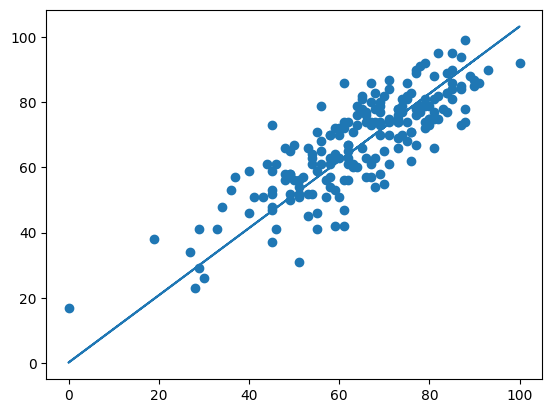

In [11]:
plt.scatter(xtest, ytest)
plt.plot(xtest, testpredict)
plt.show()